# **House Prices - Advanced Regression Techniques**

---

prediction-project

---

##Project Overview
  The goal of this project is to predict house sale prices using different property characteristics (quality, area, year built, etc).

  This is a supervised machine learning regression task based on the House Prices - Advanced Regression Techniques dataset.

##Objectives


*   Perform exploratory data analysis (EDA)

*   Handle missing values and outliers

*   Engineer meaningful features
*   Create and compare multiple regresiion models


*    Evaluate model performance using RMSE


*   Interpret vital features affecting house sale prices



##Business understanding

Accurate prediction of house prices can help:


*   Real estate agencies estimate property value
*   Buyers who are in search of a bargain prices of houses


*   Sallers set competitive prices
*   Investors analyze market opportunities

The target variable is:
- `SalePrice`










In [154]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Metrics
from sklearn.metrics import root_mean_squared_error

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 0

## Dataset Loading

In this section, the training dataset is loaded and  its basic structure is inspected.

In [155]:
df=pd.read_csv('train.csv')
print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Train-validation split:
Train-Validation Split for training and checking our future models.

In [156]:
X=df.drop("SalePrice",axis=1)
y=df["SalePrice"]
X_train,X_valid,y_train,y_valid=train_test_split(X,y, test_size=0.2,random_state=RANDOM_STATE)

#creating dataframe for eda and preprocessing
df_train=pd.concat([X_train,y_train],axis=1)
df_valid=pd.concat([X_valid,y_valid],axis=1)

## Initial Data Inspection

 Examined:
- dataset dimensions
- feature types
- missing values
- encoding
- summary statistics

In [157]:
df_train.info()

<class 'pandas.DataFrame'>
Index: 1168 entries, 618 to 684
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1168 non-null   int64  
 1   MSSubClass     1168 non-null   int64  
 2   MSZoning       1168 non-null   str    
 3   LotFrontage    956 non-null    float64
 4   LotArea        1168 non-null   int64  
 5   Street         1168 non-null   str    
 6   Alley          71 non-null     str    
 7   LotShape       1168 non-null   str    
 8   LandContour    1168 non-null   str    
 9   Utilities      1168 non-null   str    
 10  LotConfig      1168 non-null   str    
 11  LandSlope      1168 non-null   str    
 12  Neighborhood   1168 non-null   str    
 13  Condition1     1168 non-null   str    
 14  Condition2     1168 non-null   str    
 15  BldgType       1168 non-null   str    
 16  HouseStyle     1168 non-null   str    
 17  OverallQual    1168 non-null   int64  
 18  OverallCond    1168 non

In [158]:
df_train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1168.000000,1168.000000,956.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1162.000000,1168.000000,...,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000
mean,738.685788,56.605308,69.614017,10589.672945,6.086473,5.572774,1970.890411,1984.692637,103.481067,439.890411,...,94.498288,48.044521,23.022260,3.218322,14.528253,2.118151,50.936644,6.301370,2007.819349,180808.898973
std,421.609683,42.172322,22.946069,10704.180793,1.367472,1.116908,30.407486,20.684612,182.676225,435.106803,...,127.312017,68.619199,63.153093,27.916593,54.009608,36.482294,550.380636,2.725977,1.335971,78499.911304
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,373.750000,20.000000,59.000000,7589.500000,5.000000,5.000000,1953.750000,1966.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,130000.000000
50%,749.500000,50.000000,69.000000,9512.500000,6.000000,5.000000,1972.000000,1993.000000,0.000000,379.500000,...,0.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1108.750000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,167.750000,716.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,215000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,2260.000000,...,736.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [159]:
missing=df_train.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing.head(20)

PoolQC          1164
MiscFeature     1119
Alley           1097
Fence            954
MasVnrType       707
FireplaceQu      551
LotFrontage      212
GarageQual        58
GarageFinish      58
GarageType        58
GarageYrBlt       58
GarageCond        58
BsmtFinType2      29
BsmtExposure      28
BsmtQual          28
BsmtCond          28
BsmtFinType1      28
MasVnrArea         6
Electrical         1
dtype: int64

Several features contain missing values.
Further analysis is required to determine whether these values should be imputed or removed.

Several missing-value-heavy features actually indicate the absence of a property characteristic rather than missing information.

To capture this signal, binary features such as `HasGarage` and `HasPool` were created. And feature like 'LuxuryScore' shows overall sum of that features.

In [160]:
def add_binary_features(df):
    
    df["HasGarage"] = df["GarageType"].notnull().astype(int)
    df["HasPool"] = df["PoolQC"].notnull().astype(int)
    df["HasFence"] = df["Fence"].notnull().astype(int)
    df["HasAlley"] = df["Alley"].notnull().astype(int)
    
    df["LuxuryScore"] = (
        df["HasPool"] + 
        df["HasGarage"] + 
        df["HasFence"]
    )
    
    return df


df_train = add_binary_features(df_train)
df_valid = add_binary_features(df_valid)


In [161]:
#seeing whether these features are needed
new_features=["HasGarage","HasPool","HasFence","HasAlley"]
df_train[new_features+["SalePrice"]].corr()


,HasGarage,HasPool,HasFence,HasAlley,SalePrice
HasGarage,1.000000,0.013400,-0.003803,-0.057307,0.240482
HasPool,0.013400,1.000000,0.123772,-0.014913,0.025912
HasFence,-0.003803,0.123772,1.000000,-0.009342,-0.181962
HasAlley,-0.057307,-0.014913,-0.009342,1.000000,-0.122463
SalePrice,0.240482,0.025912,-0.181962,-0.122463,1.000000


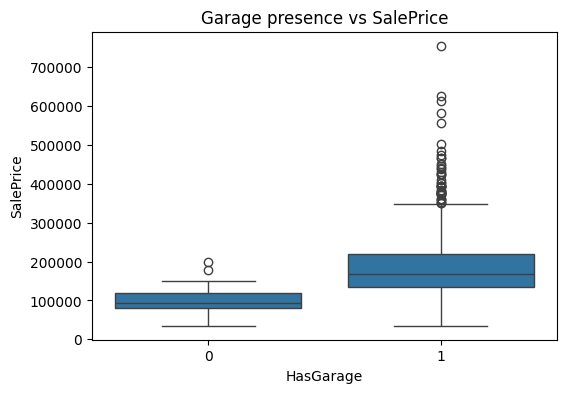

In [162]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_train["HasGarage"], y=df_train["SalePrice"])
plt.title("Garage presence vs SalePrice")
plt.show()

Properties with garages tend to have higher sale prices, indicating that garage availability is an important feature.

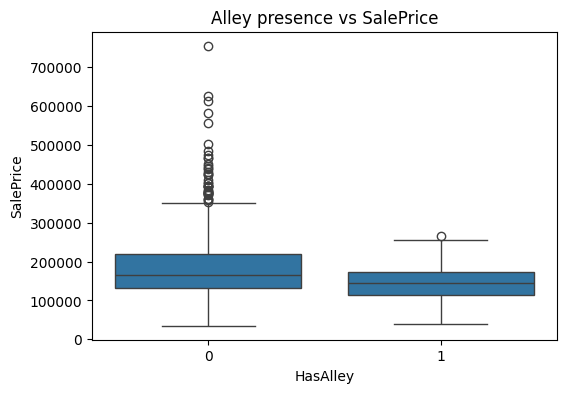

In [163]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_train["HasAlley"], y=df_train["SalePrice"])
plt.title("Alley presence vs SalePrice")
plt.show()

Properties with alleys tend to have lower sale prices, indicating that alley availability is an important feature.

In [164]:
df_train[['LuxuryScore']+["SalePrice"]].corr()

,LuxuryScore,SalePrice
LuxuryScore,1.000000,-0.036693
SalePrice,-0.036693,1.000000


The engineered feature showed weak correlation with the target variable and was therefore excluded from further modeling.

continuing with missing values:

In [165]:
num_features=df_train.select_dtypes(include=["int64","float64"])
skewness=num_features.skew().sort_values(ascending=False)
skewness.head(20)

MiscVal          22.338696
PoolArea         17.491866
HasPool          17.021969
LotArea          12.140078
3SsnPorch        10.598533
LowQualFinSF      8.606768
KitchenAbvGr      4.649547
BsmtFinSF2        4.185131
ScreenPorch       4.131186
BsmtHalfBath      4.123855
HasAlley          3.681062
EnclosedPorch     3.066627
MasVnrArea        2.713497
OpenPorchSF       2.404350
SalePrice         1.750106
LotFrontage       1.718808
HasFence          1.639868
WoodDeckSF        1.516914
MSSubClass        1.424269
GrLivArea         1.076764
dtype: float64

Many numerical features exhibit strong right-skewness.

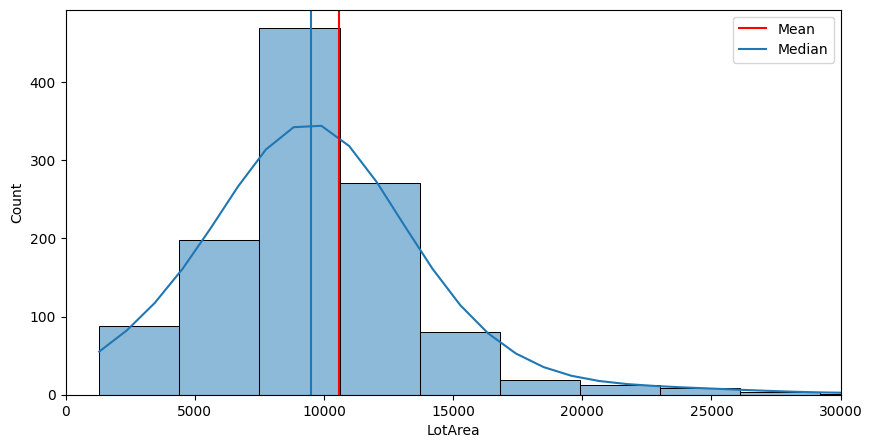

In [166]:
plt.figure(figsize=(10,5))
sns.histplot(df_train['LotArea'],kde=True)
plt.axvline(df_train['LotArea'].mean(),color="red",label="Mean")
plt.axvline(df_train['LotArea'].median(),label="Median")
plt.xlim(0, 30000)
plt.legend()
plt.show()

The distribution of `LotArea` is right-skewed with several extreme values.

The mean is shifted to the right a little due to outliers, while the median remains closer to the central mass of the data.

This supports the use of median imputation for skewed numerical features.

In [167]:
num_cols=num_features.columns
for col in num_cols:
  df_train[col]=df_train[col].fillna(df_train[col].median())
  df_valid[col]=df_valid[col].fillna(df_train[col].median())

In [168]:
cat_cols=df.select_dtypes(include=["object"]).columns
for col in cat_cols:
  df_train[col]=df_train[col].fillna("None")
  df_valid[col]=df_valid[col].fillna("None")

In [169]:
df_train.isnull().sum().sum()
#checking

np.int64(0)

Many numerical features exhibit strong right-skewness: connected to area of all house, total bathrooms,porch area,house age,remodeled age,total rooms

In [170]:

def add_features(df):
 
    df["TotalSF"] = (
        df["TotalBsmtSF"].fillna(0) +  
        df["1stFlrSF"].fillna(0) +
        df["2ndFlrSF"].fillna(0)
    )
    
   
    df["TotalBathrooms"] = (
        df["FullBath"].fillna(0) +
        (0.5 * df["HalfBath"].fillna(0)) +
        df["BsmtFullBath"].fillna(0) +
        (0.5 * df["BsmtHalfBath"].fillna(0))
    )
    
    
    df["TotalPorchSF"] = (
        df["OpenPorchSF"].fillna(0) +
        df["3SsnPorch"].fillna(0) +
        df["EnclosedPorch"].fillna(0) +
        df["ScreenPorch"].fillna(0) +
        df["WoodDeckSF"].fillna(0)
    )
    
  
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    
    
    df["RemodelAge"] = df["YrSold"] - df["YearRemodAdd"]
    
   
    df["TotalRooms"] = (
        df["TotRmsAbvGrd"].fillna(0) +
        df["BedroomAbvGr"].fillna(0)
    )
    
    return df


df_train = add_features(df_train)
df_valid = add_features(df_valid)



In [171]:
new_features = [
    "TotalSF",
    "TotalBathrooms",
    "TotalPorchSF",
    "HouseAge",
    "RemodelAge",
    "TotalRooms"
]

df_train[new_features + ["SalePrice"]].corr()

,TotalSF,TotalBathrooms,TotalPorchSF,HouseAge,RemodelAge,TotalRooms,SalePrice
TotalSF,1.000000,0.603874,0.401089,-0.345475,-0.359259,0.625423,0.816362
TotalBathrooms,0.603874,1.000000,0.309493,-0.531267,-0.467792,0.403828,0.644277
TotalPorchSF,0.401089,0.309493,1.000000,-0.083476,-0.173531,0.222642,0.378503
HouseAge,-0.345475,-0.531267,-0.083476,1.000000,0.601283,-0.040125,-0.522187
RemodelAge,-0.359259,-0.467792,-0.173531,0.601283,1.000000,-0.130225,-0.521356
TotalRooms,0.625423,0.403828,0.222642,-0.040125,-0.130225,1.000000,0.457013
SalePrice,0.816362,0.644277,0.378503,-0.522187,-0.521356,0.457013,1.000000


Added features showed high correlation results, so that they worth being included.


In [172]:
#encoding
df_all = pd.concat([df_train, df_valid], axis=0)
df_all = pd.get_dummies(df_all, drop_first=True)

train_len = len(df_train)
df_train = df_all.iloc[:train_len].copy()
df_valid = df_all.iloc[train_len:].copy()

assert (df_train.columns == df_valid.columns).all(), "Different columns"

In the following cells skewness of SalePrice is checked again. As I have mentioned before, it is skewed to the right (>1 as well).

So I will aplly log-transform to standartize extreme values, to easify regresssion in the long run

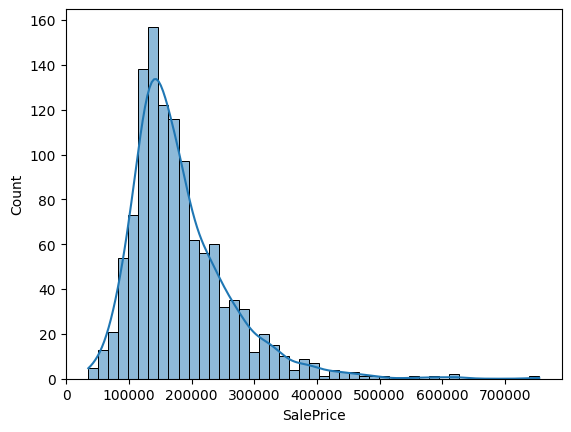

In [173]:
sns.histplot(df_train["SalePrice"], kde=True)
plt.show()

In [174]:
df_train["SalePrice"].skew()


np.float64(1.7501064882951105)

In [175]:
df_train["SalePrice"] = np.log1p(df_train["SalePrice"])
df_valid["SalePrice"] = np.log1p(df_valid["SalePrice"])

X_train=df_train.drop("SalePrice",axis=1)
y_train=df_train["SalePrice"]
X_valid=df_valid.drop("SalePrice",axis=1)
y_valid=df_valid["SalePrice"]

## Evaluation Metric

The model was evaluated using Root Mean Squared Error (RMSE).

RMSE measures the average magnitude of prediction errors and penalizes large errors more heavily due to squaring.

This metric is particularly suitable for house price prediction because large pricing errors are more significant than small ones.

## Linear Regression model

A Linear Regression model was used as the baseline approach for the regression task.

Linear Regression is simple, interpretable, and provides a useful reference point for comparing more advanced machine learning models.

In [176]:
lr=LinearRegression()
lr.fit(X_train,y_train)
preds_lr=lr.predict(X_valid)
rmse_lr=root_mean_squared_error(y_valid,preds_lr)
print(rmse_lr)

0.23744073844838187


The baseline Linear Regression model achieved an RMSE of 0.23744073844844493 on the validation set.

The result indicates that the model captures some general relationships in the data, but performance remains limited due to nonlinear patterns and complex feature interactions within the dataset.

## Random Forest Regressor model

This model performs well on structured tabular data and can capture nonlinear relationships between features. Also, it has many interaction and categorial effects.

In [177]:
rf = RandomForestRegressor(random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
preds_rf = rf.predict(X_valid)
rmse_rf = root_mean_squared_error(y_valid, preds_rf)
print(rmse_rf)

0.14442188777507886


In [178]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"],
    "RMSE": [
        rmse_lr,
        rmse_rf]
})

results

,Model,RMSE
0,Linear Regression,0.237441
1,Random Forest,0.144422


## Model Comparison: Linear vs Random Forest Regression

Random Forest achieved a lower RMSE compared to the baseline Linear Regression model.

This improvement suggests that nonlinear tree-based models are better suited for capturing complex relationships within the housing dataset.

##Feature Importance
Feature importance reflects how strongly each feature contributes to model predictions.

In [179]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
4,OverallQual,0.373242
42,TotalSF,0.367487
207,CentralAir_Y,0.023005
43,TotalBathrooms,0.019675
16,GrLivArea,0.013619
27,GarageArea,0.012832
3,LotArea,0.011070
5,OverallCond,0.009935
26,GarageCars,0.009448
9,BsmtFinSF1,0.009188


In [180]:
importance.tail(10)

,Feature,Importance
105,Condition2_RRAn,0.0
102,Condition2_PosA,0.0
104,Condition2_RRAe,0.0
64,LotConfig_FR3,0.0
144,Exterior2nd_AsphShn,0.0
139,Exterior1st_Stone,0.0
220,Functional_Sev,0.0
205,HeatingQC_Po,0.0
201,Heating_OthW,0.0
61,Utilities_NoSeWa,0.0


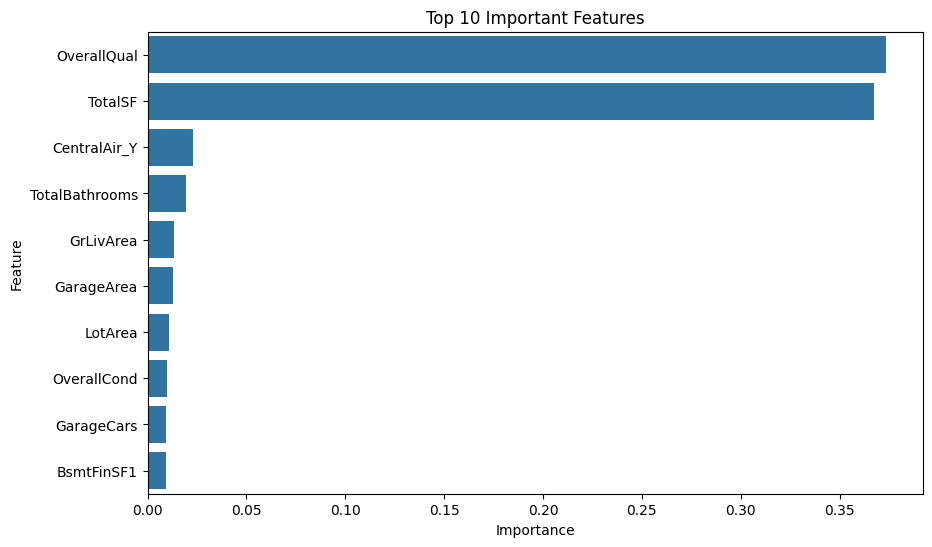

In [181]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()


Above there are top 10 features. The feature which  most affected the dataset is `OverallQual`. Also, `TotalSF` show great impact on the result.

What's more, there are about 7 features whci show total uselessness to our result.

## MI score
Mutual Information score is useful for finding some more important features.

In [182]:
mi_scores = mutual_info_regression(
    X_train,
    y_train,
    random_state=RANDOM_STATE
)

mi_scores = pd.Series(
    mi_scores,
    index=X_train.columns
)

mi_scores = mi_scores.sort_values(
    ascending=False
)

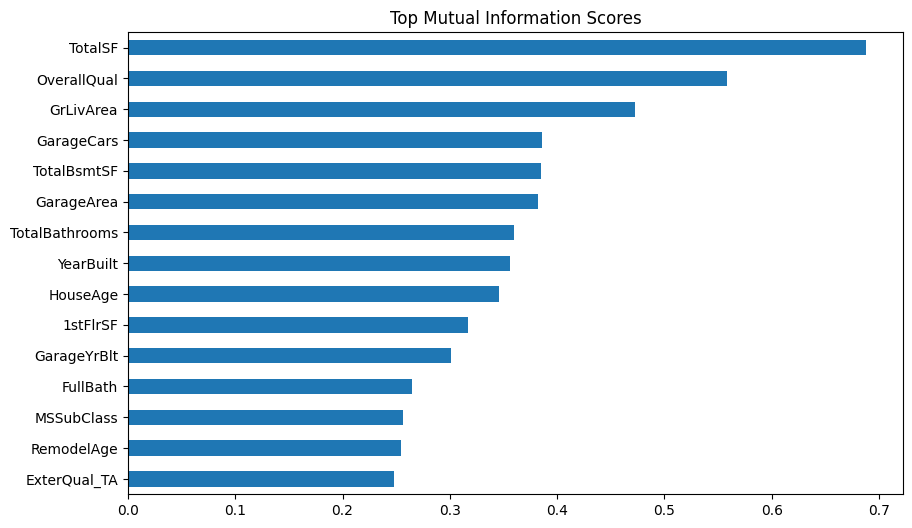

In [183]:
plt.figure(figsize=(10, 6))

mi_scores.head(15).sort_values().plot.barh()

plt.title("Top Mutual Information Scores")

plt.show()

`TotalSF` achieved the highest Mutual Information score, indicating a strong dependency with the target variable. Next goes `OverallQual` which had top 1 in feature impotance section.

`GrLivArea` shows also high MI score, whereas in feature importance it is only top 5.



## Cross Validation
This step will show whether our model might be over- or under- fitting.

So it helps us to estimate our model across different data splits.

In [184]:
cv_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

cv_rmse = -cv_scores.mean()

print(cv_rmse)

0.14130027847933


Cross-validation confirmed that the Random Forest model achieved an RMSE of 0.14413184510332777 on the validation set, significantly outperforming the baseline Linear Regression model.

This improvement suggests that tree-based models are more effective at capturing nonlinear relationships and feature interactions within the housing dataset.

##GradientBoostingRegressor
While Random Forest builds independent trees in parallel and averages their results (bagging), Gradient Boostingbuilds trees sequentially. Each new tree corrects the errors of the previous ones. Boosting usually achieves higher accuracy but requires more careful tuning to avoid overfitting.

In [185]:
gbr = GradientBoostingRegressor(
    random_state=RANDOM_STATE)

gbr.fit(X_train, y_train)

preds_gbr = gbr.predict(X_valid)
rmse_gbr = root_mean_squared_error(
    y_valid,
    preds_gbr)

print(rmse_gbr)

0.13234154706518736


In [186]:
cv_scores_gbr = cross_val_score(
    gbr,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

cv_rmse_gbr = -cv_scores_gbr.mean()

print(cv_rmse_gbr)

0.1301003902668085


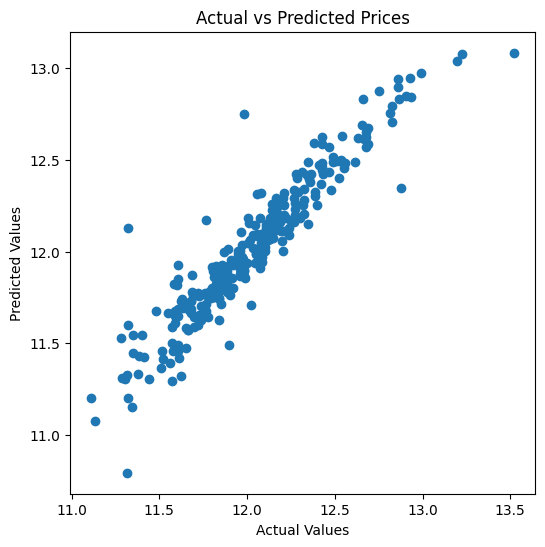

In [187]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_valid,
    preds_gbr
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Prices")

plt.show()

Gradient Boosting achieved the best performance among the evaluated models.

This result suggests that boosting methods are highly effective for structured tabular datasets due to their ability to iteratively correct prediction errors.

## Limitations

The project uses relatively simple preprocessing and default model hyperparameters.

Further improvements could be achieved through:
- advanced hyperparameter tuning,
- ensemble methods,
- additional feature engineering,
- SHAP-based interpretability analysis.

## Conclusion

In [188]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_gbr]
})

results

,Model,RMSE
0,Linear Regression,0.237441
1,Random Forest,0.144422
2,Gradient Boosting,0.132342



In this project, several machine learning techniques were applied to predict house prices using the House Prices dataset.

The workflow included:
- exploratory data analysis,
- missing value handling,
- feature engineering,
- categorical encoding,
- model training and evaluation.

Several engineered features such as `TotalSF` and `TotalBathrooms` improved the representation of property characteristics and contributed to model performance.

A baseline Linear Regression model was first implemented to establish a reference point. However, due to nonlinear relationships within the dataset, tree-based models achieved significantly better results.

Among the evaluated models, Gradient Boosting achieved the best performance with the lowest RMSE score, outperforming both Linear Regression and Random Forest.

Feature importance analysis showed that variables related to overall quality, living area, and total square footage had the strongest impact on house prices.

Overall, this project demonstrated the importance of data preprocessing, feature engineering, and model selection in building effective machine learning solutions for structured tabular data.

Possible future improvements include:
- hyperparameter tuning,
- XGBoost or LightGBM models,
- advanced interpretability techniques such as SHAP values.